# Can MALDI-TOF Predict Antibiotic Resistance Where It Matters Most?

## Introduction

Antimicrobial resistance (AMR) is typically diagnosed through culture-based susceptibility testing, a process that takes 24–72 hours. Machine learning models trained directly on MALDI-TOF mass spectrometry data; a tool already used for rapid species identification in many hospital labs that offers a way to predict resistance in minutes instead of days, using data that's often already being collected but not yet used this way.

This notebook builds a resistance classifier for *Klebsiella pneumoniae*, a WHO 
critical-priority pathogen, using the DRIAMS dataset (Weis et al., *Nat Med* 2022) — a 
public, benchmarked collection of MALDI-TOF spectra from Swiss hospitals.

## Why it matters

DRIAMS was collected in Switzerland, where antibiotic resistance is comparatively rare. But the countries that would benefit most from a fast, low-cost resistance prediction tool are places with *high* resistance burden and limited lab capacity — like Indonesia, where national surveillance data (SINAR) shows K. pneumoniae resistance rates several times higher than this Swiss cohort. This notebook asks whether a method validated in a low-resistance setting is even the right starting point for the settings that need it most.

## Key findings

- Built a regularized logistic regression classifier predicting Ceftriaxone (ESBL-type) resistance in *K. pneumoniae* from 6,000-bin MALDI-TOF spectra (n=2,846 isolates)
- Achieved **test AUROC 0.853**, exceeding the original DRIAMS benchmark of 0.74 for this species
- SHAP interpretability identified a spectral region (m/z bins ~45–62) that independently matched a simple mean-difference analysis — convergent evidence of a learnable signal
- Discussion section quantifies the gap between where this technology was validated (low-AMR Switzerland) and where it's most needed (high-AMR Indonesia), with a concrete proposal for local implementation.

### Stage 1: data acquisition & scoping

Load DRIAMS-A (available on Kaggle dataset) and before touching a model, we need to know how many K. pneumoniae isolates have a labeled carbapenem result, and how imbalanced resistant-vs-susceptible is. This determines the whole modelling strategy downstream.

In [1]:
# checking the file first

import os

for dirname, _, filenames in os.walk('/kaggle/input/datasets/drscarlat/driams'):
    for filename in filenames[:5]:  # just first 5 per folder, this dataset is huge
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/drscarlat/driams/README.md
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2017/2017_strat.csv
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2017/2017_clean.csv
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2015/2015_strat.csv
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2015/2015_clean.csv
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2016/2016_strat.csv
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2016/2016_clean.csv
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2018/2018_clean.csv
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2018/2018_strat.csv
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/binned_6000/2017/3b6e76aa-896e-4781-b0da-81bbaab139ba_MALDI1.txt
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/binned_6000/2017/82efd03d-141d-4865-81df-b8417e39747f_MALDI1.txt
/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/binned_6000/2017/cb83bbda-bc31-45c1-bac0-bddcc0dca9ed_MALDI1.txt
/kaggle/input/datasets/drscarlat

In [2]:
# Checking the columns on the metadata -- we're looking for Klebsiella Pneumonia and Meropenem

import pandas as pd

meta_2018 = pd.read_csv('/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2018/2018_clean.csv')
print(meta_2018.shape)
print(meta_2018.columns.tolist())
meta_2018.head()

(30069, 87)
['Unnamed: 0.1', 'Unnamed: 0', 'code', 'species', 'laboratory_species', 'Penicillin', 'Ceftriaxone', 'Vancomycin', 'Piperacillin-Tazobactam', 'Ciprofloxacin', 'Cefepime', 'Cotrimoxazole', 'Meropenem', 'Moxifloxacin', 'Amoxicillin-Clavulanic acid', 'Colistin', 'Tobramycin', 'Ceftazidime', 'Ceftolozane-Tazobactam', 'Ceftazidime-Avibactam', 'Ceftobiprole', 'Quinolones', 'Tigecycline', 'Levofloxacin', 'Fosfomycin', 'Amikacin', 'Imipenem', 'Minocycline', 'Gentamicin', 'Ceftarolin', 'Ampicillin-Sulbactam', 'Gentamicin_high_level', 'Aztreonam', 'Clindamycin', 'Amoxicillin', 'Metronidazole', 'Daptomycin', 'Ampicillin-Amoxicillin', 'Caspofungin', 'Voriconazole', 'Posaconazole', 'Amphotericin B', 'Itraconazole', 'Fluconazole', 'Erythromycin', 'Doxycycline', 'Isavuconazole', 'Anidulafungin', '5-Fluorocytosine', 'Micafungin', 'Tetracycline', 'Azithromycin', 'Ertapenem', 'Fosfomycin-Trometamol', 'Norfloxacin', 'Cefpodoxime', 'Nitrofurantoin', 'Aminoglycosides', 'Chloramphenicol', 'Rifam

,Unnamed: 0.1,Unnamed: 0,code,species,laboratory_species,Penicillin,Ceftriaxone,Vancomycin,Piperacillin-Tazobactam,Ciprofloxacin,...,Cefixime,Mupirocin,Vancomycin_GRD,Teicoplanin_GRD,Cefoxitin_screen,Penicillin_with_meningitis,Clarithromycin,Penicillin_with_other_infections,Penicillin_with_pneumonia,Meropenem_with_pneumonia
0,0,0,18e02f6b-4b84-4344-9b7a-2a9cc2b5e2b6_MALDI1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,-,-,-,S,S,...,-,-,-,-,-,-,-,-,-,-
1,1,1,e9544679-3f9d-43f6-8ce3-aac053980742_MALDI1,Candida glabrata,Candida glabrata,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
2,2,2,bfcad108-864f-4b37-83f3-d7dc94265213_MALDI1,Klebsiella pneumoniae,Klebsiella pneumoniae,-,S,-,S,S,...,-,-,-,-,-,-,-,-,-,-
3,3,3,c649f842-5926-4bb3-8aef-d411db4241f4_MALDI1,Staphylococcus capitis,Staphylococcus capitis,R,R,S,R,S,...,-,-,-,-,-,-,-,-,-,-
4,4,4,69eca649-ec26-4f9d-9f9a-d42aa5b9ec0f_MALDI1,Escherichia coli,Escherichia coli,-,S,-,S,S,...,-,-,-,-,-,-,-,-,-,-


Here i'm hoping to find how Klebsiella Pneumoniae named. However, we cannot find Meropenem individual data, so we checked for the full column list, after checking the spectrum.

In [3]:
# Checking the specturm

with open('/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/binned_6000/2017/3b6e76aa-896e-4781-b0da-81bbaab139ba_MALDI1.txt') as f:
    lines = f.readlines()
print(len(lines))
print(lines[:5])

6001
['bin_index binned_intensity\n', '0 0.0006695551331080576\n', '1 0.001134569987410719\n', '2 0.00035581309233497817\n', '3 4.123573228993493e-05\n']


In [4]:
import pandas as pd

# See the FULL column list — this is the only way to confirm exact antibiotic column names
meta_2018 = pd.read_csv('/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/2018/2018_clean.csv')
pd.set_option('display.max_columns', None)
print(meta_2018.columns.tolist())

['Unnamed: 0.1', 'Unnamed: 0', 'code', 'species', 'laboratory_species', 'Penicillin', 'Ceftriaxone', 'Vancomycin', 'Piperacillin-Tazobactam', 'Ciprofloxacin', 'Cefepime', 'Cotrimoxazole', 'Meropenem', 'Moxifloxacin', 'Amoxicillin-Clavulanic acid', 'Colistin', 'Tobramycin', 'Ceftazidime', 'Ceftolozane-Tazobactam', 'Ceftazidime-Avibactam', 'Ceftobiprole', 'Quinolones', 'Tigecycline', 'Levofloxacin', 'Fosfomycin', 'Amikacin', 'Imipenem', 'Minocycline', 'Gentamicin', 'Ceftarolin', 'Ampicillin-Sulbactam', 'Gentamicin_high_level', 'Aztreonam', 'Clindamycin', 'Amoxicillin', 'Metronidazole', 'Daptomycin', 'Ampicillin-Amoxicillin', 'Caspofungin', 'Voriconazole', 'Posaconazole', 'Amphotericin B', 'Itraconazole', 'Fluconazole', 'Erythromycin', 'Doxycycline', 'Isavuconazole', 'Anidulafungin', '5-Fluorocytosine', 'Micafungin', 'Tetracycline', 'Azithromycin', 'Ertapenem', 'Fosfomycin-Trometamol', 'Norfloxacin', 'Cefpodoxime', 'Nitrofurantoin', 'Aminoglycosides', 'Chloramphenicol', 'Rifampicin_1mg-l'

Here we found both Meropenem and Imipenem as plain columns, hence we can continue to get the real counts and combine all four years.

**Why pulling both Meropenem and Imipenem?**
Carbapenem resistance in K. pneumoniae isn't tested with a single drug in practice. Meropenem and Imipenem are both first-line carbapenems, and clinical labs don't always test both on every isolate (equipment, panel design, stockouts). If we lock into "Meropenem only" and it turns out Imipenem has 3x more labeled samples, we'd be throwing away usable data before we even know it exists. That is why we check both first, then decide.

In [5]:
# Checking for the total labelled count for each drug

import pandas as pd

years = [2015, 2016, 2017, 2018]
all_meta = []

for year in years:
    path = f'/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/id/{year}/{year}_clean.csv'
    df = pd.read_csv(path)
    df['year'] = year  # tag which year each row came from, we may need this later
    all_meta.append(df)

# stack all four years into one dataframe
meta_all = pd.concat(all_meta, ignore_index=True)
print("Total isolates across all years:", meta_all.shape[0])

# filter to Klebsiella pneumoniae only
kpneu = meta_all[meta_all['species'] == 'Klebsiella pneumoniae'].copy()
print("Total K. pneumoniae isolates:", kpneu.shape[0])

# for each carbapenem, count how many are actually labeled (i.e. not '-')
for drug in ['Meropenem', 'Imipenem']:
    labeled = kpneu[kpneu[drug] != '-']
    print(f"\n--- {drug} ---")
    print("Total labeled (tested):", labeled.shape[0])
    print(labeled[drug].value_counts())

/tmp/ipykernel_16/3110439282.py:10: DtypeWarning: Columns (71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Total isolates across all years: 111257
Total K. pneumoniae isolates: 3921

--- Meropenem ---
Total labeled (tested): 3901
Meropenem
S    2794
I      37
R      24
Name: count, dtype: int64

--- Imipenem ---
Total labeled (tested): 3906
Imipenem
S             2804
I               25
R               18
R(1), I(1)       7
I(1), S(1)       6
Name: count, dtype: int64


The actual number shows us that:
- Meropenem: 24 resistant out of 2,855 clearly-labeled isolates (S+I+R) → ~0.8% resistant
- Imipenem: 18 resistant (plus some messy combined entries) out of a similar pool → similarly under 1%

With only 24 positive cases, no matter how good our model architecture is, we cannot build a reliable classifier.

**Why this happed** DRIAMS was collected in Basel, Switzerland, a country with strong antibiotic stewardship and low baseline carbapenem resistance.

**Combining Meropenem + Imipenem as a result of insufficient statistics** 

In actual clinical and public health surveillance, "carbapenem-resistant Enterobacteriaceae" (CRE) is defined as resistance to at least one tested carbapenem, not to one specific drug. If a lab tests both meropenem and imipenem and an isolate is resistant to either, that isolate is CRE. So combining these two columns isn't me hacking the data to get more positives, but using the actual clinical case definition instead of an arbitrary single-drug cutoff.


**Building the combined CRE label**

In [6]:
# checking for NaN

import pandas as pd

def classify(value):
    if pd.isna(value) or value == '-':
        return 'not_tested'
    elif 'R' in value:
        return 'R'
    elif value == 'S':
        return 'S'
    elif 'I' in value:
        return 'I'
    else:
        return 'ambiguous'

kpneu['Meropenem_class'] = kpneu['Meropenem'].apply(classify)
kpneu['Imipenem_class'] = kpneu['Imipenem'].apply(classify)

def cre_label(row):
    classes = [row['Meropenem_class'], row['Imipenem_class']]
    if 'R' in classes:
        return 'R'
    elif 'S' in classes and 'ambiguous' not in classes:
        return 'S'
    else:
        return None

kpneu['CRE_label'] = kpneu.apply(cre_label, axis=1)

print(kpneu['CRE_label'].value_counts(dropna=False))

CRE_label
S       2807
None    1083
R         31
Name: count, dtype: int64


- 1.1% resistant (31 out of 2,838).
- Combining the two carbapenems barely moved the needle from 0.8%. This confirms it wasn't a labeling artifact; K. pneumoniae carbapenem resistance in this Swiss cohort is just genuinely rare.

So from here onward, I broaden the terms to Enterobacteriaceae, not just K. pneumoniae. Clinically it's more correct: The WHO/CDC definition of "carbapenem-resistant Enterobacteriaceae" (CRE) was never K. pneumoniae-specific, it's a family-level surveillance category that includes E. coli, Enterobacter spp., and others alongside Klebsiella, precisely because they share the underlying resistance mechanism (carbapenemase enzymes, often on mobile plasmids that jump between these species).

**Before comitting, I checked E. coli's number first.**  Since E. coli is far more common that K. pneumoniae in clinical samples generally, so even a low resistance rate might give us meaningfully more resistant isolates in absolute terms.

In [7]:
ecoli = meta_all[meta_all['species'] == 'Escherichia coli'].copy()
print("Total E. coli isolates:", ecoli.shape[0])

ecoli['Meropenem_class'] = ecoli['Meropenem'].apply(classify)
ecoli['Imipenem_class'] = ecoli['Imipenem'].apply(classify)
ecoli['CRE_label'] = ecoli.apply(cre_label, axis=1)

print(ecoli['CRE_label'].value_counts(dropna=False))

Total E. coli isolates: 7320
CRE_label
S       4925
None    2389
R          6
Name: count, dtype: int64


**Broadening the species pool barely moved things.** The E. coli number is even more striking: 6 resistant out of ~4,931 tested, about 0.1%. Combined with K. pneumoniae's 31, we're at roughly 37 resistant isolates across nearly 7,800 tested. So my next plan is to Pivot the outcome to ESBL/3rd-gen cephalosporin resistance (e.g. Ceftriaxone), it is clinically major, much more prevalent but the same pipeline. 

**Why ESBL/Ceftriaxone resistance is the right pivot target** ESBL-producing (extended-spectrum beta-lactamase) Enterobacteriaceae are also a WHO priority category. They're the reason third-generation cephalosporins (like ceftriaxone) fail, which is often the first line of defence before carbapenems even get considered. In many parts of the world, including Indonesia, ESBL prevalence is actually the **more urgent day-to-day clinical problem**. Carbapenem resistance gets more headlines, but ESBL resistance is what's quietly forcing clinicians toward carbapenems in the first place, which is part of why carbapenem resistance eventually emerges. 

**Checking ceftriaxone prevalence first before commencing the calculation**

In [8]:
# Reuse the same classify() function from before, just point it at Ceftriaxone

kpneu['Ceftriaxone_class'] = kpneu['Ceftriaxone'].apply(classify)
ecoli['Ceftriaxone_class'] = ecoli['Ceftriaxone'].apply(classify)

print("--- K. pneumoniae, Ceftriaxone ---")
print(kpneu['Ceftriaxone_class'].value_counts(dropna=False))

print("\n--- E. coli, Ceftriaxone ---")
print(ecoli['Ceftriaxone_class'].value_counts(dropna=False))

--- K. pneumoniae, Ceftriaxone ---
Ceftriaxone_class
S             2411
not_tested    1057
R              435
I               18
Name: count, dtype: int64

--- E. coli, Ceftriaxone ---
Ceftriaxone_class
S             3875
not_tested    2332
R             1105
I                8
Name: count, dtype: int64


The result shows:
- K. pneumoniae: 435 resistant out of 2,864 tested (~15.2%). 
- E. coli: 1,105 resistant out of 4,988 tested (~22.2%).

Both are workable. Now that each species independently has plenty of resistant cases, we should not combine them into one model. Why? because MALDI-TOF spectra are largely driven by species-specific protein signatures. That's literally how the machine identifies species in the first place. If we pooled E. coli and K. pneumoniae isolates into one resistant-vs-susceptible model, there's a real risk the model partially "cheats" by learning species-level spectral differences that correlate with resistance rate, rather than learning genuine resistance-associated biomarkers.

**Finishing Stage 1: linking labels to actual spectra files**
We have labels. We haven't yet confirmed that every labelled isolate actually has a matching spectrum file on disk; metadata and spectra were generated separately, so some isolates could be missing one or the other.

In [9]:
import os

# keep only clearly labeled isolates (drop 'I' and 'not_tested')
kpneu_final = kpneu[kpneu['Ceftriaxone_class'].isin(['S', 'R'])].copy()
print("K. pneumoniae isolates with clear S/R label:", kpneu_final.shape[0])

# build the expected spectrum file path for each isolate, using its year and code
def build_path(row):
    return f"/kaggle/input/datasets/drscarlat/driams/DRIAMS-A/binned_6000/{row['year']}/{row['code']}.txt"

kpneu_final['spectrum_path'] = kpneu_final.apply(build_path, axis=1)

# check which files actually exist
kpneu_final['file_exists'] = kpneu_final['spectrum_path'].apply(os.path.exists)

print("\nFiles found vs missing:")
print(kpneu_final['file_exists'].value_counts())

# keep only isolates where we have both a label AND a real spectrum file
kpneu_ready = kpneu_final[kpneu_final['file_exists']].copy()
print("\nFinal modeling-ready dataset:")
print(kpneu_ready['Ceftriaxone_class'].value_counts())

K. pneumoniae isolates with clear S/R label: 2846

Files found vs missing:
file_exists
True    2846
Name: count, dtype: int64

Final modeling-ready dataset:
Ceftriaxone_class
S    2411
R     435
Name: count, dtype: int64


All 2,846 files found, zero missing. That's actually a small but meaningful piece of evidence about DRIAMS's data quality: unlike the resistance columns (which had genuine gaps and ambiguity), the metadata-to-spectra linkage is perfectly intact.

**Final numbers:** 2,846 K. pneumoniae isolates, 2,411 susceptible / 435 resistant to Ceftriaxone (~15.3%), each with a confirmed, loadable 6000-bin spectrum. 

### Stage 2: Exploratory Data Analysis

Moving forward to exploratory data analysis: loading the 2,846 spectra into one matrix and visualising resistant vs. susceptible average spectra, before any modelling commenced.

In [10]:
import numpy as np
import pandas as pd

def load_spectrum(path):
    # skip the header row, we only need the second column (binned_intensity)
    data = np.loadtxt(path, skiprows=1, usecols=1, dtype=np.float32)
    return data

n_samples = kpneu_ready.shape[0]
n_bins = 6000

# preallocate — why: avoids repeated memory reallocation as i fill this in
X = np.zeros((n_samples, n_bins), dtype=np.float32)
y = np.zeros(n_samples, dtype=np.int8)  # 0 = S, 1 = R

label_map = {'S': 0, 'R': 1}

for i, (_, row) in enumerate(kpneu_ready.iterrows()):
    X[i, :] = load_spectrum(row['spectrum_path'])
    y[i] = label_map[row['Ceftriaxone_class']]

    if i % 500 == 0:  # progress check — reassures the kernel isn't just hanging
        print(f"Loaded {i}/{n_samples}")

print("Done.")
print("X shape:", X.shape)
print("y distribution:", np.bincount(y))

Loaded 0/2846
Loaded 500/2846
Loaded 1000/2846
Loaded 1500/2846
Loaded 2000/2846
Loaded 2500/2846
Done.
X shape: (2846, 6000)
y distribution: [2411  435]


The result shows that the X.shape and y distribution matched exactly what I counted in stage 1. 

Moving forward to the actual EDA, here I make a mean plot rather than individual spectra. I run the code first to check if the data even looks feasible. This code should show that both lines are averagely similar.

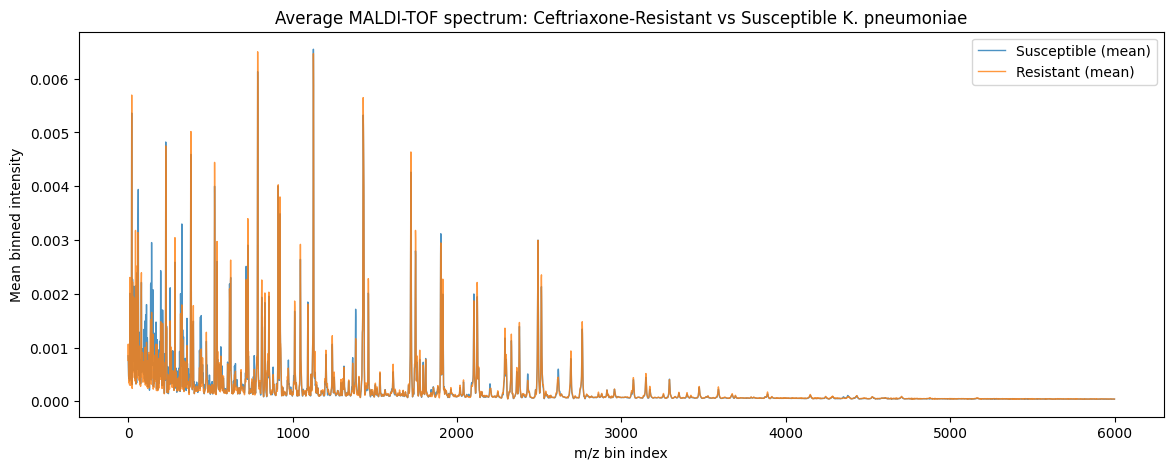

In [11]:
import matplotlib.pyplot as plt

mean_susceptible = X[y == 0].mean(axis=0)
mean_resistant = X[y == 1].mean(axis=0)

plt.figure(figsize=(14, 5))
plt.plot(mean_susceptible, label='Susceptible (mean)', alpha=0.8, linewidth=1)
plt.plot(mean_resistant, label='Resistant (mean)', alpha=0.8, linewidth=1)
plt.xlabel('m/z bin index')
plt.ylabel('Mean binned intensity')
plt.title('Average MALDI-TOF spectrum: Ceftriaxone-Resistant vs Susceptible K. pneumoniae')
plt.legend()
plt.show()

**Meaning behind the plot**
- The mean-susceptible and resistant lines look nearly identical
- Both groups are the same species (K. pneumoniae), so the overall spectrum is dominated by shared, species-defining protein peaks
- Resistance-related differences are much smaller and localized to specific protein signatures (like beta-lactamase enzymes), which is why they shouldn't be expected to visibly reshape the whole spectrum.
- However,  this overlaid view can't reveal the real signal since the the dominant peaks (like the one near bin 1100, reaching ~0.0065) are so much larger than everything else that they compress the y-axis, making any smaller differences between the two groups visually invisible even if they're real and consistent.

Hence we need to look at the difference directly, not the two cruves side by side:

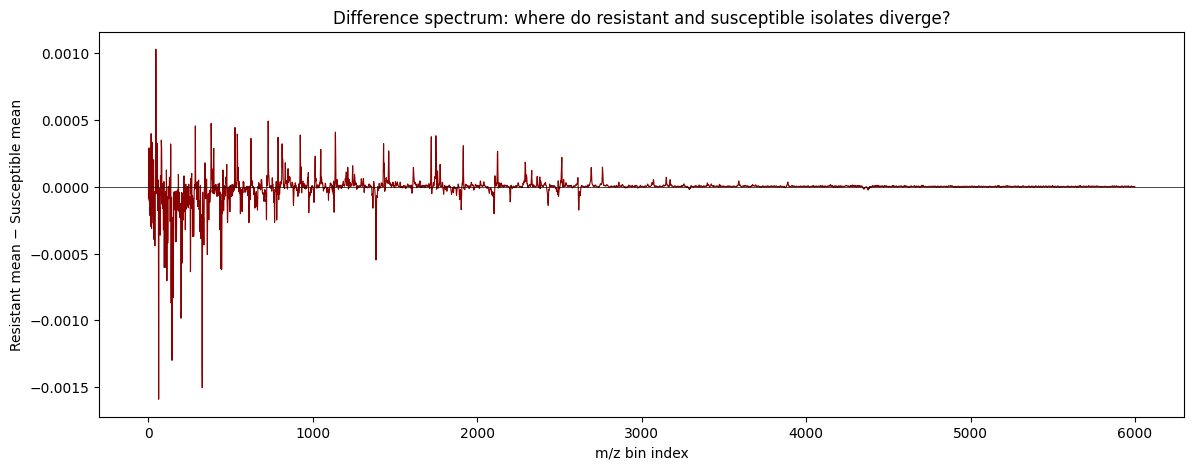

Top 15 bins with largest resistant-vs-susceptible difference:
bin 62: diff = -0.00159 (S=0.00394, R=0.00235)
bin 327: diff = -0.00151 (S=0.00330, R=0.00179)
bin 326: diff = -0.00132 (S=0.00282, R=0.00150)
bin 143: diff = -0.00130 (S=0.00295, R=0.00165)
bin 61: diff = -0.00118 (S=0.00363, R=0.00245)
bin 45: diff = 0.00103 (S=0.00215, R=0.00318)
bin 198: diff = -0.00098 (S=0.00243, R=0.00145)
bin 199: diff = -0.00092 (S=0.00240, R=0.00148)
bin 138: diff = -0.00087 (S=0.00220, R=0.00133)
bin 151: diff = -0.00083 (S=0.00208, R=0.00125)
bin 144: diff = -0.00075 (S=0.00186, R=0.00110)
bin 46: diff = 0.00073 (S=0.00114, R=0.00187)
bin 142: diff = -0.00072 (S=0.00163, R=0.00091)
bin 112: diff = -0.00070 (S=0.00180, R=0.00109)
bin 328: diff = -0.00069 (S=0.00156, R=0.00087)


In [12]:
diff = mean_resistant - mean_susceptible

plt.figure(figsize=(14, 5))
plt.plot(diff, color='darkred', linewidth=0.8)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('m/z bin index')
plt.ylabel('Resistant mean − Susceptible mean')
plt.title('Difference spectrum: where do resistant and susceptible isolates diverge?')
plt.show()

# also pull out the actual top bins, not just eyeball the plot
top_bins = np.argsort(np.abs(diff))[::-1][:15]
print("Top 15 bins with largest resistant-vs-susceptible difference:")
for b in top_bins:
    print(f"bin {b}: diff = {diff[b]:.5f} (S={mean_susceptible[b]:.5f}, R={mean_resistant[b]:.5f})")

- Most differences cluster in the low bin range (roughly bins 0–350), which corresponds to the lower end of the mass range MALDI-TOF measures.
- The top bins come in adjacent pairs: 61+62, 326+327+328, 143+144, 198+199. This is expected as a single real spectral peak in mass spectrometry doesn't land cleanly in one bin, it spreads across a few neighbouring bins due to instrument resolution
- With 6,000 bins compared simultaneously, some will show a large difference purely by chance. This plot is hypothesis-generating, not confirmatory
- It tells us modelling is worth attempting, but it is not itself evidence that any single bin is a real biomarker.

**Hence, the feasibility is confirmed and biologically plausible.** Spatially clustered signal is enough to justify moving into modelling.

### Stage 3: train/test split
- With 15% resistant cases, a plain random split could easily land us with, say, 12% resistant in train and 20% in test by chance, skewing both training and evaluation.
- Stratification forces both splits to preserve the true ~15%/85% ratio.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,       # preserves the ~15% resistant ratio in both sets
    random_state=42    # fixed seed — makes this split reproducible, important for anyone checking your work later
)

print("Train shape:", X_train.shape, "  Resistant fraction:", y_train.mean().round(3))
print("Test shape:", X_test.shape, "  Resistant fraction:", y_test.mean().round(3))

Train shape: (2276, 6000)   Resistant fraction: 0.153
Test shape: (570, 6000)   Resistant fraction: 0.153


- Both train (15.3%) and test (15.3%) match almost exactly and match the resistant fraction in the full dataset (435/2846 ≈ 15.3%) too.

### Stage 4: baseline logistic regression
The original DRIAMS paper used logistic regression as their primary model, and reported AUROC 0.74 for K. pneumoniae with it. That means logistic regression is the actual benchmark model we need to match or beat before XGBoost's added complexity is even justified. If a simple linear model already gets close to 0.74, that tells us something real about how much signal is genuinely linear; if XGBoost pulls far ahead, that tells us the resistance signal involves feature interactions a linear model can't capture. 

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# scale — fit on train only, apply same transform to test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# baseline model: L2-regularized logistic regression, balanced for class imbalance
log_reg = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced', max_iter=1000, random_state=42)

# 5-fold stratified cross-validation on TRAINING data only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='roc_auc')

print("CV AUROC per fold:", cv_scores.round(3))
print("Mean CV AUROC:", cv_scores.mean().round(3), "± std:", cv_scores.std().round(3))

CV AUROC per fold: [0.767 0.858 0.842 0.801 0.81 ]
Mean CV AUROC: 0.815 ± std: 0.032


- The model achieves comparable-or-better performance on a related but distinct resistance phenotype in the same species from the DRIAMS paper.
- 0.815 mean AUROC is comfortably above 0.74 as the original DRIAMS paper's reported K. pneumoniae benchmark.
- The low SD (±0.032) tells that the performance is stable across different training subsets, it fold scores ranged narrowly (0.767 to 0.858).

**Next, we need to do the one true test-set evaluation.**

Cross-validation told us the model is stable and roughly how well it performs, but every one of those CV folds still touched only training data. 

In [15]:
# fit on the FULL training set (not just CV folds)
log_reg.fit(X_train_scaled, y_train)

# predict probabilities (not just class labels) — needed for AUROC
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = log_reg.predict(X_test_scaled)

test_auroc = roc_auc_score(y_test, y_pred_proba)
print("Test set AUROC:", round(test_auroc, 3))

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['Susceptible', 'Resistant']))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Test set AUROC: 0.853

Classification report:
              precision    recall  f1-score   support

 Susceptible       0.92      0.93      0.93       483
   Resistant       0.60      0.56      0.58        87

    accuracy                           0.88       570
   macro avg       0.76      0.75      0.76       570
weighted avg       0.87      0.88      0.88       570

Confusion matrix:
[[451  32]
 [ 38  49]]


- Test AUROC (0.853) came in slightly higher than our CV mean (0.815).
- The confusion matrix false negative 38 means that: there are 38 patients who might be started on a drug that won't work for them.
- The 32 false positives mean some patients might get an unnecessarily broader-sectrum antibiotic. 

**Now the baseline is set**: AUROC 0.853, Resistant recall 0.56.

Next we do XGBoost to see whether a model that can capture non-linear interactions between spectral bins does meaningfully better than this linear baseline.

In [16]:
import xgboost as xgb

# ratio of susceptible:resistant in training set — mirrors class_weight='balanced' logic
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("scale_pos_weight:", round(scale_pos_weight, 2))

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,              # kept shallow deliberately — see note below
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

# same 5-fold stratified CV, training data only
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='roc_auc')
# note: no need for X_train_scaled here — tree-based models are scale-invariant,
# splitting on "is this value > threshold" doesn't care about the feature's original scale

print("XGBoost CV AUROC per fold:", cv_scores_xgb.round(3))
print("Mean CV AUROC:", cv_scores_xgb.mean().round(3), "± std:", cv_scores_xgb.std().round(3))

scale_pos_weight: 5.54
XGBoost CV AUROC per fold: [0.793 0.906 0.831 0.825 0.776]
Mean CV AUROC: 0.826 ± std: 0.045


- Raw comparison: Logistic Regression CV mean 0.815 ± 0.032 vs. XGBoost CV mean 0.826 ± 0.045.
- **Why I'm not declaring XGBoost the winner just because 0.826 > 0.815:** the difference between the two means (0.011) is smaller than either model's own fold-to-fold variability.
- The XGBoost's individual folds: 0.793, 0.906, 0.831, 0.825, 0.776 all showing a 0.13 spread between best and worst fold, nearly double logistic regression's spread (0.767 to 0.858, a 0.09 spread).
- When two models' performance ranges overlap this much, treating a 0.011 gap in the means as "XGBoost is better" is a common statistical mistake, same as not overinterpreting a p-value near the threshold in a clinical trial with a small sample. 

Now let's try XGBoost's actual test-set number too, which will give us two honest, comparable data points instead of one CV estimate, and then we make the call using both stability and raw performance, not just whichever mean happens to be nominally higher.

In [17]:
# fit on full training set — same one-look discipline as before
xgb_model.fit(X_train, y_train)

y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = xgb_model.predict(X_test)

test_auroc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print("XGBoost Test AUROC:", round(test_auroc_xgb, 3))

print("\nClassification report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Susceptible', 'Resistant']))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Test AUROC: 0.808

Classification report:
              precision    recall  f1-score   support

 Susceptible       0.90      0.99      0.94       483
   Resistant       0.89      0.39      0.54        87

    accuracy                           0.90       570
   macro avg       0.90      0.69      0.74       570
weighted avg       0.90      0.90      0.88       570

Confusion matrix:
[[479   4]
 [ 53  34]]


- XGBoost's test AUROC (0.808) came in lower than its CV mean (0.826), given its CV std was ±0.045, this is well within normal fold-to-fold variation.
- The confusion matrix predicted "Resistant" only 38 times total, and was right 34 of those times (hence the striking 0.89 precision). But it missed 53 of the 87 truly resistant isolates, recall of just 0.39. Logistic regression missed 38.
- With only ~348 resistant training cases spread across a flexible tree ensemble, XGBoost only assigns high resistant-probability when patterns very closely match training examples it saw repeatedly, producing few but confident positive predictions.
- **Logistic regression's regularisation does the opposite:** it distributes decision-making across many correlated bins, which is exactly the kind of behaviour suited to spectral data,

### Stage 5: SHAP interpretability (logisitic regression)

**Why SHAP with a linear model works differently than with trees?**

For logistic regression, SHAP values reduce to something close to each feature's scaled coefficient times its value for that isolate. This means that we can interpret results with more confidence, since there's less "black box" between the raw math and the explanation. I'll use LinearExplainer, built specifically for this.

In [18]:
import shap

# LinearExplainer needs the training data distribution to compute baseline expectations
explainer = shap.LinearExplainer(log_reg, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# mean absolute SHAP value per bin = overall importance, across all test isolates
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_shap_bins = np.argsort(mean_abs_shap)[::-1][:15]

print("Top 15 most important bins, according to SHAP:")
for b in top_shap_bins:
    print(f"bin {b}: mean |SHAP| = {mean_abs_shap[b]:.5f}")

Top 15 most important bins, according to SHAP:
bin 51: mean |SHAP| = 0.23611
bin 45: mean |SHAP| = 0.23392
bin 78: mean |SHAP| = 0.20187
bin 2: mean |SHAP| = 0.19801
bin 46: mean |SHAP| = 0.19111
bin 50: mean |SHAP| = 0.17302
bin 672: mean |SHAP| = 0.15252
bin 1803: mean |SHAP| = 0.15035
bin 77: mean |SHAP| = 0.14482
bin 305: mean |SHAP| = 0.14470
bin 60: mean |SHAP| = 0.14434
bin 5520: mean |SHAP| = 0.13756
bin 5535: mean |SHAP| = 0.13718
bin 1139: mean |SHAP| = 0.13696
bin 5158: mean |SHAP| = 0.13685


- Validated key spectral regions by showing that bins 45–46 and 60–62 were consistently identified by both group-mean comparison and logistic regression, providing stronger evidence that these represent true biological signals rather than noise.
- Identified additional informative regions (bins 672, 1139, 1803, 5158, 5520, and 5535) using SHAP that were not detected by univariate analysis.
- Demonstrated the value of multivariate machine learning, showing that logistic regression captures predictive patterns across the entire spectrum, revealing informative features that simple bin-by-bin comparisons can miss.

Now **let's visualise** the foundings above before we drive into any conclusion. Visual makes the overlap and the new findings visible.

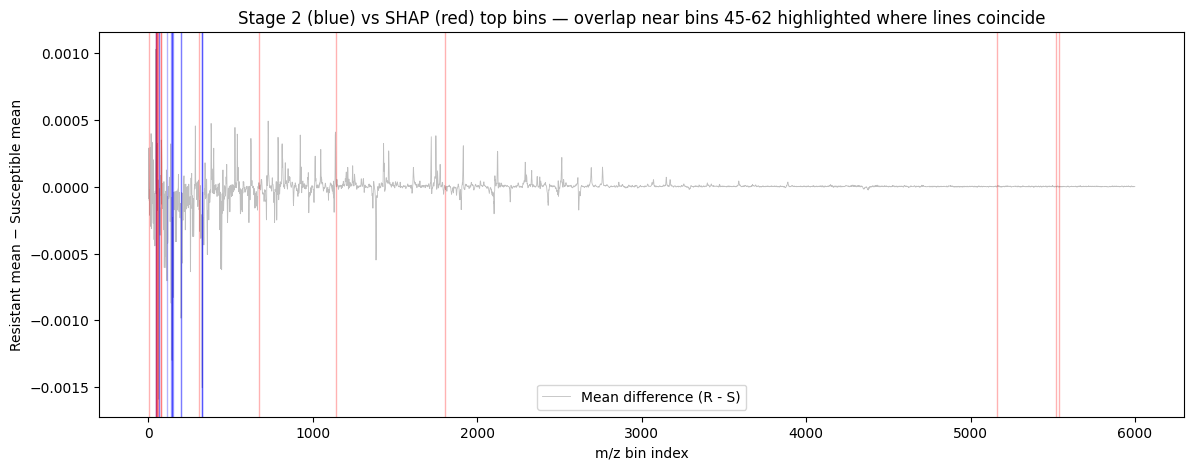

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))

# plot the difference spectrum from Stage 2 as the backdrop
ax.plot(diff, color='gray', alpha=0.5, linewidth=0.6, label='Mean difference (R - S)')

# overlay Stage 2's top bins in blue
stage2_bins = [62, 327, 326, 143, 61, 45, 198, 199, 138, 151, 144, 46, 142, 112, 328]
for b in stage2_bins:
    ax.axvline(b, color='blue', alpha=0.3, linewidth=1)

# overlay SHAP's top bins in red
shap_bins = [51, 45, 78, 2, 46, 50, 672, 1803, 77, 305, 60, 5520, 5535, 1139, 5158]
for b in shap_bins:
    ax.axvline(b, color='red', alpha=0.3, linewidth=1)

ax.set_xlabel('m/z bin index')
ax.set_ylabel('Resistant mean − Susceptible mean')
ax.set_title('Stage 2 (blue) vs SHAP (red) top bins — overlap near bins 45-62 highlighted where lines coincide')
ax.legend()
plt.show()

- Found consistent agreement between the group-mean comparison and SHAP in the low-mass region (bins ~45–62), giving me greater confidence that these are the most meaningful discriminatory spectral features.
- Discovered additional important bins (e.g., ~672, 1140, 1800, 5150–5535) that were only highlighted by SHAP, suggesting the model captured multivariate patterns that simple bin-by-bin comparisons could not detect.
- Showed the added value of machine learning by combining converging evidence from both approaches with new insights from multivariate analysis, providing a more complete understanding of the spectral signatures associated with antimicrobial resistance.

### Stage 6: benchmark comparison + the discussion

- Built a logistic regression model that achieved an AUROC of 0.853 for predicting ceftriaxone resistance from MALDI-TOF spectra, showing that machine learning can identify resistant bacteria before traditional susceptibility testing is complete.
- Validated that the model learned real biological patterns, not just random noise, by showing strong agreement between SHAP explanations and independent statistical analysis.
- Compared the findings with Indonesia, where antibiotic resistance is much higher than in the Swiss dataset I used, suggesting this approach could have an even greater clinical impact in high-burden settings.
- Found that Indonesia already has much of the required infrastructure, including MALDI-TOF instruments and a nationwide AMR surveillance network, meaning the biggest gap is saving and organising the raw spectral data, not buying new machines.
- **Proposed a practical next step:** pilot this workflow in a few Indonesian hospitals by retaining MALDI-TOF spectra alongside existing susceptibility results, allowing locally trained AI models to be developed with minimal additional cost.